In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, gaussian_filter
from skimage import data, transform, img_as_float
from skimage.draw import disk
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['image.cmap'] = 'gray'

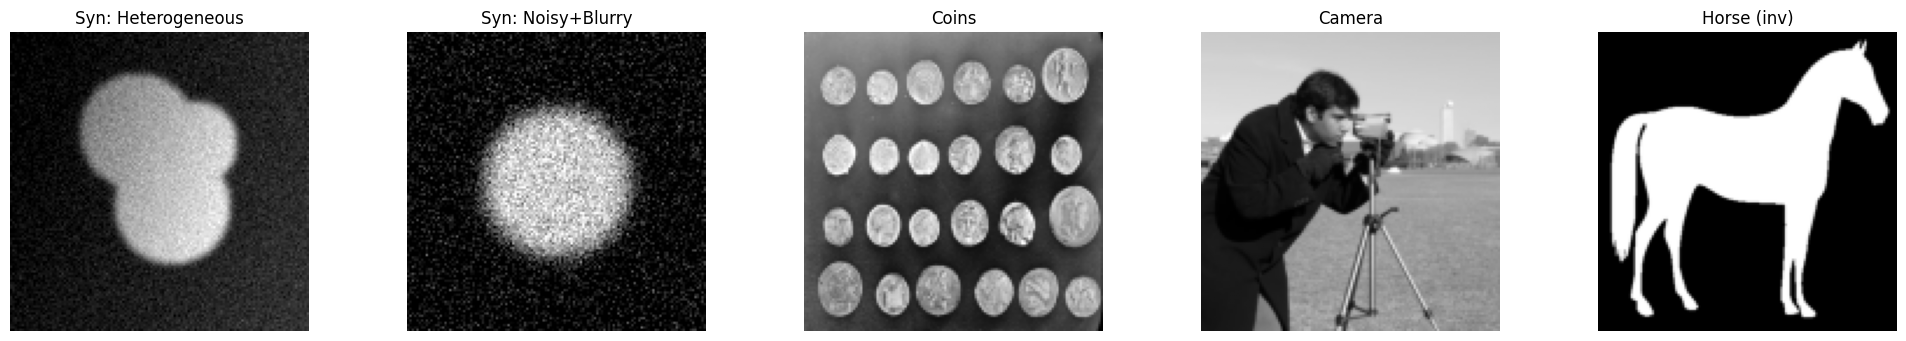

In [11]:
np.random.seed(42)

def create_synthetic_heterogeneous(size=128):
    """Intensity heterogeneity: object fades across a bias field."""
    img = np.zeros((size, size), dtype=np.float64)
    x, y = np.linspace(-1, 1, size), np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)
    bias = 0.5 + 0.4 * X + 0.15 * Y
    rr1, cc1 = disk((size//3, size//2-10), size//5, shape=img.shape)
    rr2, cc2 = disk((size//2+10, size//2+5), size//5, shape=img.shape)
    rr3, cc3 = disk((size//3+5, size//2+15), size//7, shape=img.shape)
    mask = np.zeros_like(img, dtype=bool)
    mask[rr1, cc1] = True; mask[rr2, cc2] = True; mask[rr3, cc3] = True
    img[~mask] = 0.15 * bias[~mask]
    img[mask] = 0.7 * bias[mask] + 0.2
    img = gaussian_filter(img, sigma=1.5)
    img += 0.03 * np.random.randn(size, size)
    return np.clip(img, 0, 1), mask

def create_synthetic_noisy(size=128):
    """Noisy image with blurry boundaries."""
    img = np.zeros((size, size), dtype=np.float64)
    rr, cc = disk((size//2, size//2), size//4, shape=img.shape)
    mask = np.zeros_like(img, dtype=bool); mask[rr, cc] = True
    img[rr, cc] = 0.8
    img = gaussian_filter(img, sigma=4)
    img += 0.12 * np.random.randn(size, size)
    return np.clip(img, 0, 1), mask

syn1, gt1 = create_synthetic_heterogeneous(128)
syn2, gt2 = create_synthetic_noisy(128)
coins = transform.resize(img_as_float(data.coins()), (128, 128), anti_aliasing=True)
cam   = transform.resize(img_as_float(data.camera()), (128, 128), anti_aliasing=True)
horse = 1.0 - transform.resize(img_as_float(data.horse()), (128, 128), anti_aliasing=True)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, img, t in zip(axes,
    [syn1, syn2, coins, cam, horse],
    ['Syn: Heterogeneous', 'Syn: Noisy+Blurry', 'Coins', 'Camera', 'Horse (inv)']):
    ax.imshow(img); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

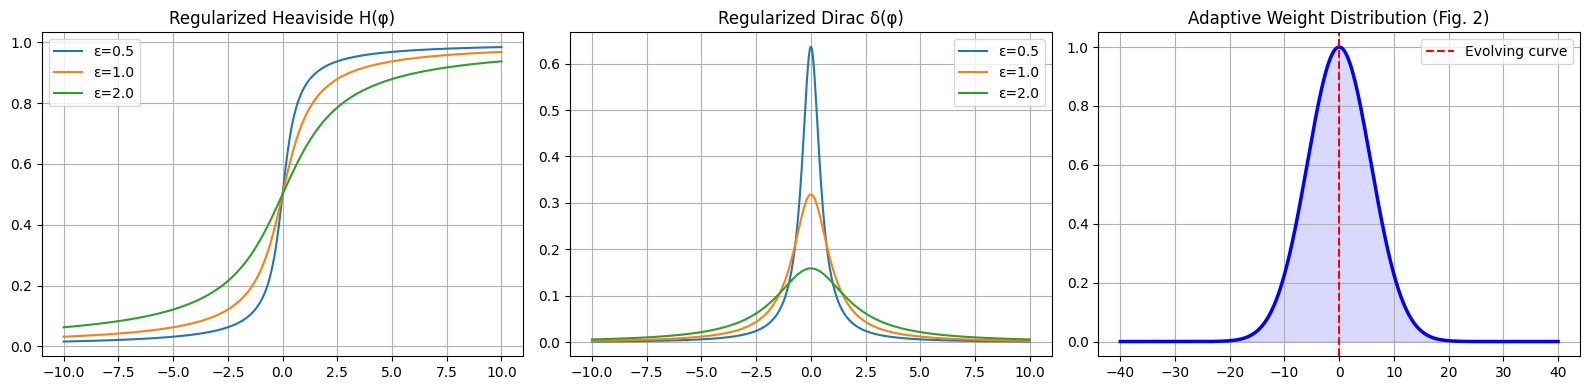

In [12]:
# ── Regularized Heaviside and Dirac (Section 2.1) ──────────────────────

def heaviside(phi, eps=1.0):
    """H(φ) = 0.5 * (1 + (2/π) * arctan(φ/ε))"""
    return 0.5 * (1.0 + (2.0 / np.pi) * np.arctan(phi / eps))

def dirac(phi, eps=1.0):
    """δ(φ) = (1/π) * (ε / (ε² + φ²))"""
    return (1.0 / np.pi) * (eps / (eps**2 + phi**2))

# ── Neumann boundary conditions ────────────────────────────────────────

def neumann_bc(phi):
    phi[0, :] = phi[1, :];  phi[-1, :] = phi[-2, :]
    phi[:, 0] = phi[:, 1];  phi[:, -1] = phi[:, -2]
    return phi

# ── Mean curvature: κ = div(∇φ/|∇φ|) ──────────────────────────────────

def curvature_central(phi):
    fy  = (np.roll(phi, -1, 0) - np.roll(phi, 1, 0)) / 2.0
    fx  = (np.roll(phi, -1, 1) - np.roll(phi, 1, 1)) / 2.0
    fyy = np.roll(phi, -1, 0) - 2*phi + np.roll(phi, 1, 0)
    fxx = np.roll(phi, -1, 1) - 2*phi + np.roll(phi, 1, 1)
    fxy = (np.roll(np.roll(phi,-1,0),-1,1) - np.roll(np.roll(phi,-1,0),1,1)
         - np.roll(np.roll(phi, 1,0),-1,1) + np.roll(np.roll(phi, 1,0),1,1)) / 4.0
    grad2 = fx**2 + fy**2 + 1e-10
    return (fxx * fy**2 - 2*fx*fy*fxy + fyy * fx**2) / (grad2 ** 1.5)

# ── Level set initialization ───────────────────────────────────────────

def init_phi(shape, center, radius, method='rect', c0=2.0):
    """
    Initialize φ: +c0 inside the contour, −c0 outside.
    Small values keep φ within the effective band of the Dirac function.
    """
    rows, cols = shape
    mask = np.zeros(shape, dtype=bool)
    if method == 'rect':
        r0, r1 = max(center[0]-radius, 0), min(center[0]+radius, rows)
        c0_, c1 = max(center[1]-radius, 0), min(center[1]+radius, cols)
        mask[r0:r1, c0_:c1] = True
    elif method == 'circle':
        Y, X = np.ogrid[:rows, :cols]
        mask = ((X - center[1])**2 + (Y - center[0])**2) <= radius**2
    elif method == 'checker':
        Y, X = np.mgrid[:rows, :cols]
        mask = np.sin(np.pi * X / 5) * np.sin(np.pi * Y / 5) > 0
    return np.where(mask, c0, -c0).astype(np.float64)

# ── Global info: c+, c− (Eq. 3) ───────────────────────────────────────

def compute_c(image, phi, eps=1.0):
    H = heaviside(phi, eps)
    c1 = np.sum(image * H) / (np.sum(H) + 1e-10)
    c2 = np.sum(image * (1 - H)) / (np.sum(1 - H) + 1e-10)
    return c1, c2

# ── Local info: m+, m− (Eq. 6) ────────────────────────────────────────

def compute_m(image, phi, radius, eps=1.0):
    H = heaviside(phi, eps)
    sz = 2 * radius + 1
    m1 = uniform_filter(H * image, sz) / (uniform_filter(H, sz) + 1e-10)
    m2 = uniform_filter((1-H) * image, sz) / (uniform_filter(1-H, sz) + 1e-10)
    return m1, m2

# ── Adaptive Gaussian weights: ω (Eq. 13) ─────────────────────────────

def compute_omega(phi):
    """Pixels near zero level set get highest weight (Gaussian decay)."""
    d_norm = np.abs(phi) / (np.max(np.abs(phi)) + 1e-10) * 2.58
    return np.exp(-d_norm**2 / 2.0)

# ── Visualize Heaviside, Dirac, and Weight distribution ────────────────

phi_range = np.linspace(-10, 10, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for eps in [0.5, 1.0, 2.0]:
    axes[0].plot(phi_range, heaviside(phi_range, eps), label=f'ε={eps}')
    axes[1].plot(phi_range, dirac(phi_range, eps), label=f'ε={eps}')
axes[0].set_title('Regularized Heaviside H(φ)'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Regularized Dirac δ(φ)');     axes[1].legend(); axes[1].grid(True)

dist = np.linspace(-40, 40, 500)
w = np.exp(-((dist / 15) * 2.58)**2 / 2.0); w /= w.max()
axes[2].plot(dist, w, 'b-', lw=2.5)
axes[2].fill_between(dist, w, alpha=0.15, color='blue')
axes[2].axvline(0, color='r', ls='--', label='Evolving curve')
axes[2].set_title('Adaptive Weight Distribution (Fig. 2)'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

In [ ]:
def run_cv(image, phi0, niters=1000, dt=5.0, mu=0.1, eps=1.0, sigma=0.5):
    """
    Chan-Vese global model (Eq. 4):
      ∂φ/∂t = δ(φ)[ μ·κ − (I−c₁)² + (I−c₂)² ]
    """
    phi = phi0.copy()
    energies = []
    for i in range(niters):
        neumann_bc(phi)
        c1, c2 = compute_c(image, phi, eps)
        dphi = dirac(phi, eps) * (mu * curvature_central(phi)
                                  - (image - c1)**2 + (image - c2)**2)
        phi = gaussian_filter(phi + dt * dphi, sigma=sigma)
        energies.append(np.sum(np.abs(dphi)))
        if i > 50 and abs(energies[-1] - energies[-2]) / (energies[-2] + 1e-10) < 1e-5:
            break
    return phi, energies


def run_lrb(image, phi0, niters=1000, dt=5.0, mu=0.1, radius=10, eps=1.0, sigma=0.5):
    """
    Local Region-Based model (Eq. 8):
      ∂φ/∂t = δ(φ)[ μ·κ − (I−m₁)² + (I−m₂)² ]
    """
    phi = phi0.copy()
    energies = []
    for i in range(niters):
        neumann_bc(phi)
        neumann_bc(phi)
        m1, m2 = compute_m(image, phi, radius, eps)
        dphi = dirac(phi, eps) * (mu * curvature_central(phi)
                                  - (image - m1)**2 + (image - m2)**2)
        phi = gaussian_filter(phi + dt * dphi, sigma=sigma)
        energies.append(np.sum(np.abs(dphi)))
        if i > 50 and abs(energies[-1] - energies[-2]) / (energies[-2] + 1e-10) < 1e-5:
            break
    return phi, energies


def run_hybrid(image, phi0, niters=1000, dt=5.0, mu=0.1, radius=None, eps=1.0, sigma=0.5):
    """
    Proposed Hybrid Model (Eq. 12):
      ∂φ/∂t = δ(φ)[ 2·E₁·E₂ + μ·κ ]
      E₁ = ω·c₁ − ω·c₂    (adaptive weighted global term)
      E₂ = I − (m₁+m₂)/2   (local correction term)
    """
    if radius is None:
        radius = max(image.shape) // 10
    phi = phi0.copy()
    energies = []
    for i in range(niters):
        neumann_bc(phi)
        c1, c2 = compute_c(image, phi, eps)
        m1, m2 = compute_m(image, phi, radius, eps)
        omega  = compute_omega(phi)
        E1 = omega * c1 - omega * c2
        E2 = image - (m1 + m2) / 2.0
        dphi = dirac(phi, eps) * (2.0 * E1 * E2 + mu * curvature_central(phi))
        phi = gaussian_filter(phi + dt * dphi, sigma=sigma)
        energies.append(np.sum(np.abs(dphi)))
        if i > 50 and abs(energies[-1] - energies[-2]) / (energies[-2] + 1e-10) < 1e-5:
            break
    return phi, energies

print("Models defined: run_cv (Eq.4), run_lrb (Eq.8), run_hybrid (Eq.12)")

Models defined: run_cv (Eq.4), run_lrb (Eq.8), run_hybrid (Eq.12)


Processing Syn: Heterogeneous... 3.3s
Processing Syn: Noisy+Blurry... 2.9s
Processing Coins... 2.0s
Processing Camera... 4.1s
Processing Horse... 3.1s


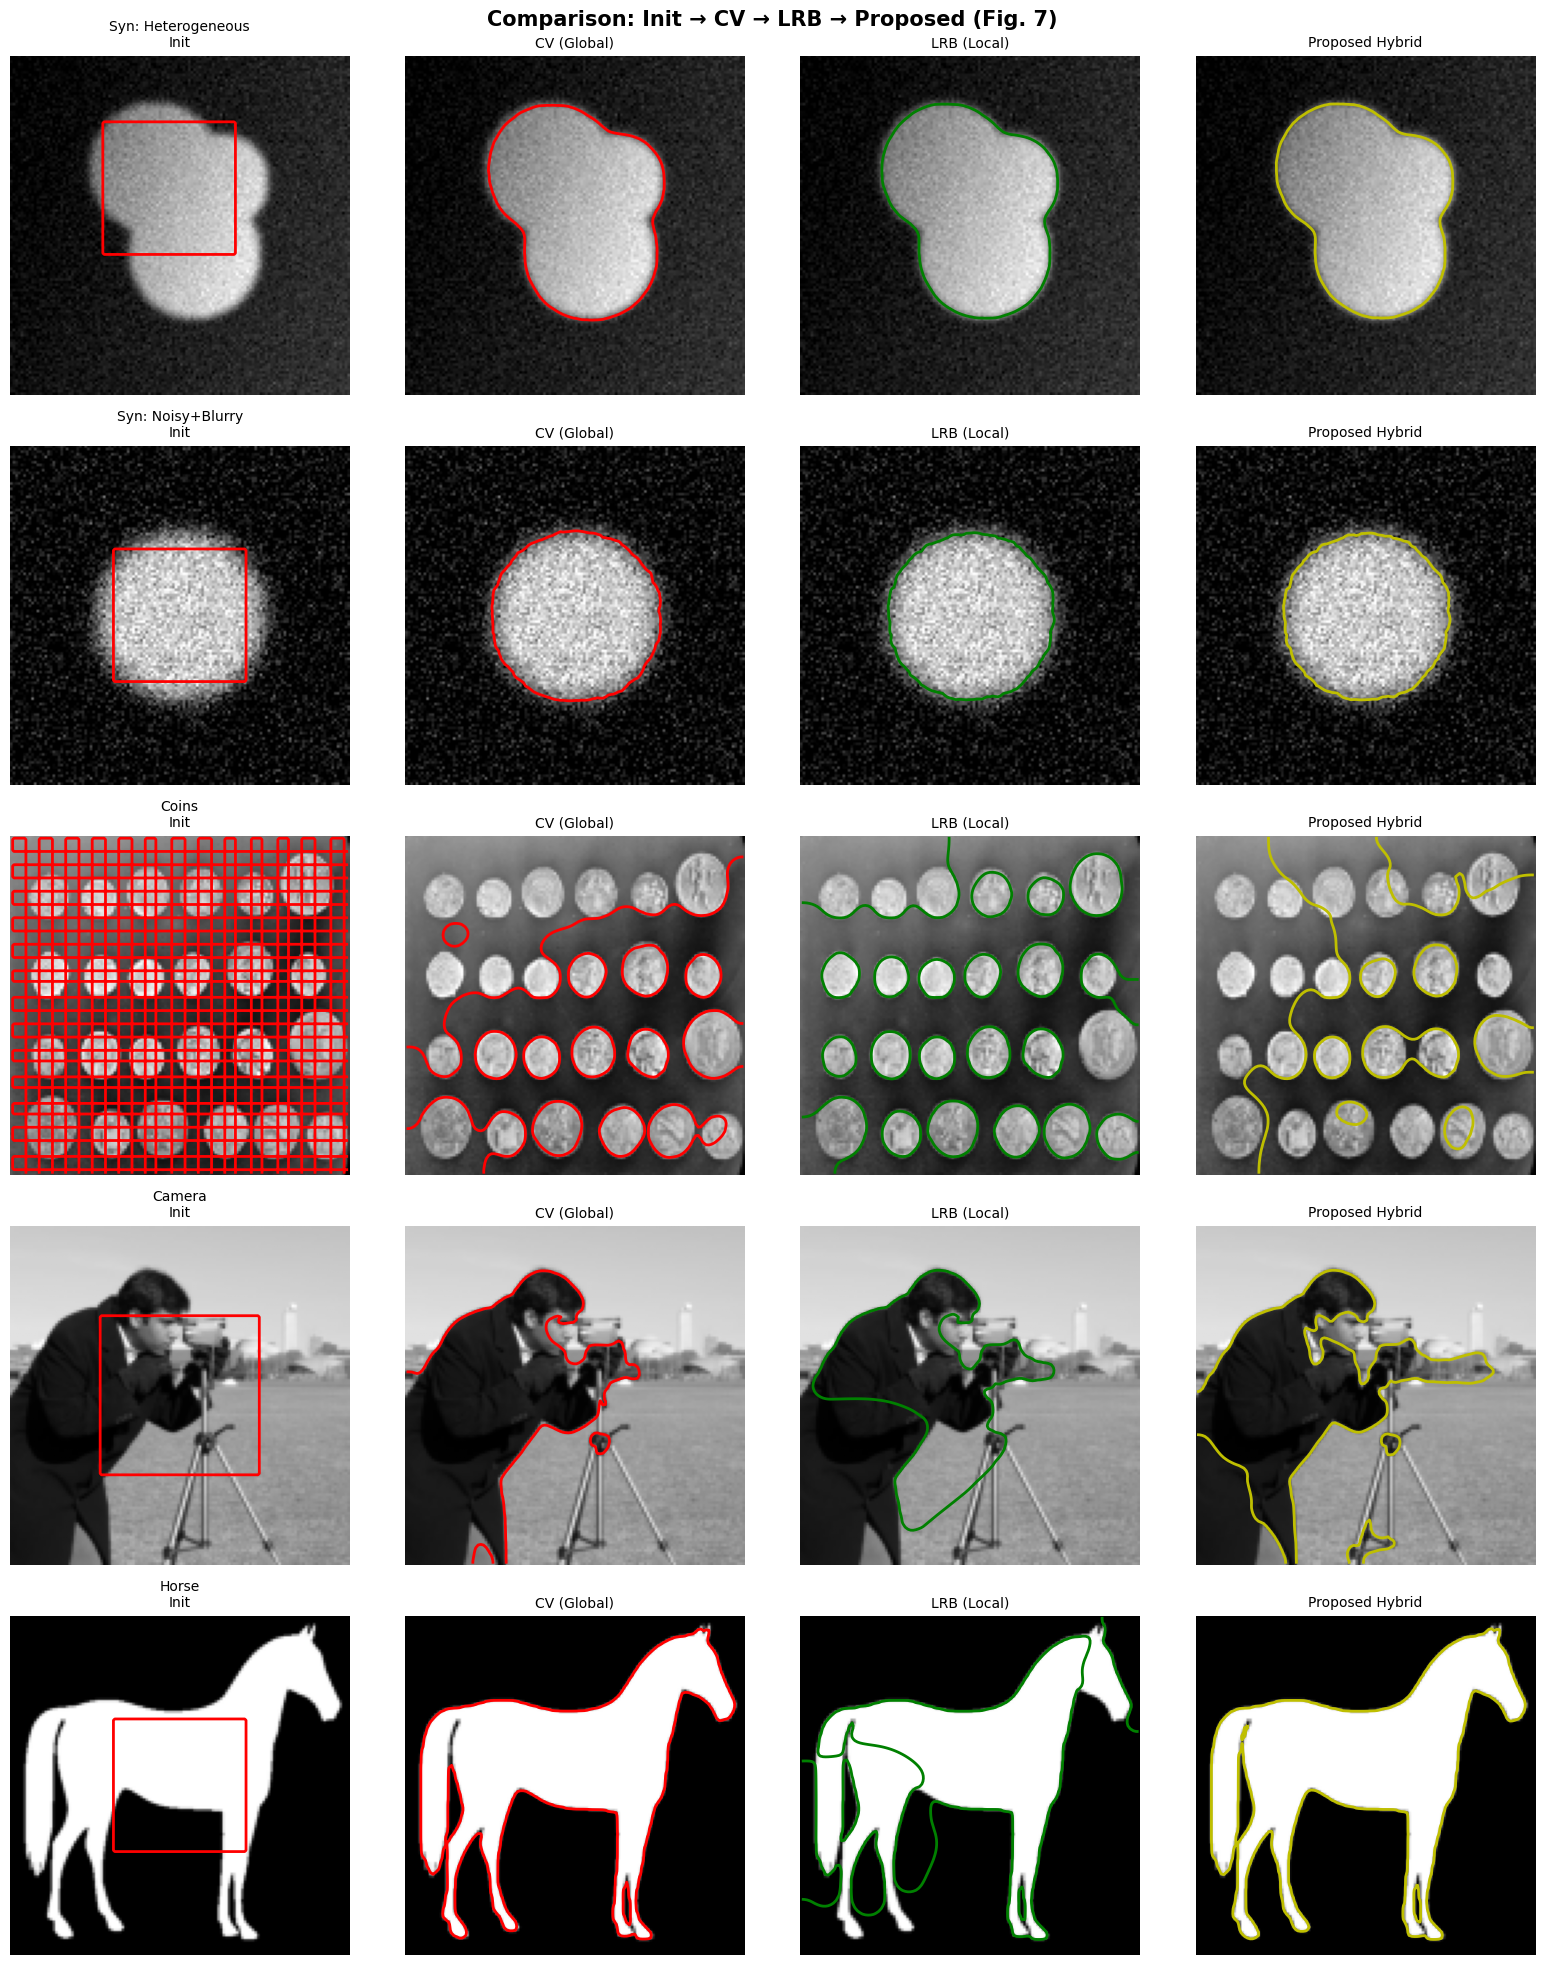

In [14]:
test_cases = [
    ('Syn: Heterogeneous', syn1, (50,60), 25, 'rect',    dict(dt=5.0, mu=0.1,  niters=1000)),
    ('Syn: Noisy+Blurry',  syn2, (64,64), 25, 'rect',    dict(dt=5.0, mu=0.1,  niters=1000)),
    ('Coins',              coins,(64,64), 30, 'checker',  dict(dt=5.0, mu=0.05, niters=1000)),
    ('Camera',             cam,  (64,64), 30, 'rect',     dict(dt=5.0, mu=0.05, niters=1500)),
    ('Horse',              horse,(64,64), 25, 'rect',     dict(dt=5.0, mu=0.05, niters=1500)),
]

fig, axes = plt.subplots(len(test_cases), 4, figsize=(16, 4 * len(test_cases)))
fig.suptitle('Comparison: Init → CV → LRB → Proposed (Fig. 7)',
             fontsize=15, fontweight='bold')

all_energies = {}

for row, (name, img, center, rad, init_method, params) in enumerate(test_cases):
    phi0 = init_phi(img.shape, center, rad, init_method)
    r = max(img.shape) // 10

    print(f"Processing {name}...", end=" ", flush=True)
    t0 = time.time()
    phi_cv,  e_cv  = run_cv(img,  phi0.copy(), **params)
    phi_lrb, e_lrb = run_lrb(img, phi0.copy(), radius=r, **params)
    phi_hyb, e_hyb = run_hybrid(img, phi0.copy(), radius=r, **params)
    print(f"{time.time()-t0:.1f}s")

    all_energies[name] = (e_cv, e_lrb, e_hyb)

    for col, (phi, title, clr) in enumerate([
        (phi0,    f'{name}\nInit',   'r'),
        (phi_cv,  'CV (Global)',     'r'),
        (phi_lrb, 'LRB (Local)',     'g'),
        (phi_hyb, 'Proposed Hybrid', 'y'),
    ]):
        axes[row, col].imshow(img)
        axes[row, col].contour(phi, [0], colors=clr, linewidths=2)
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout(); plt.show()

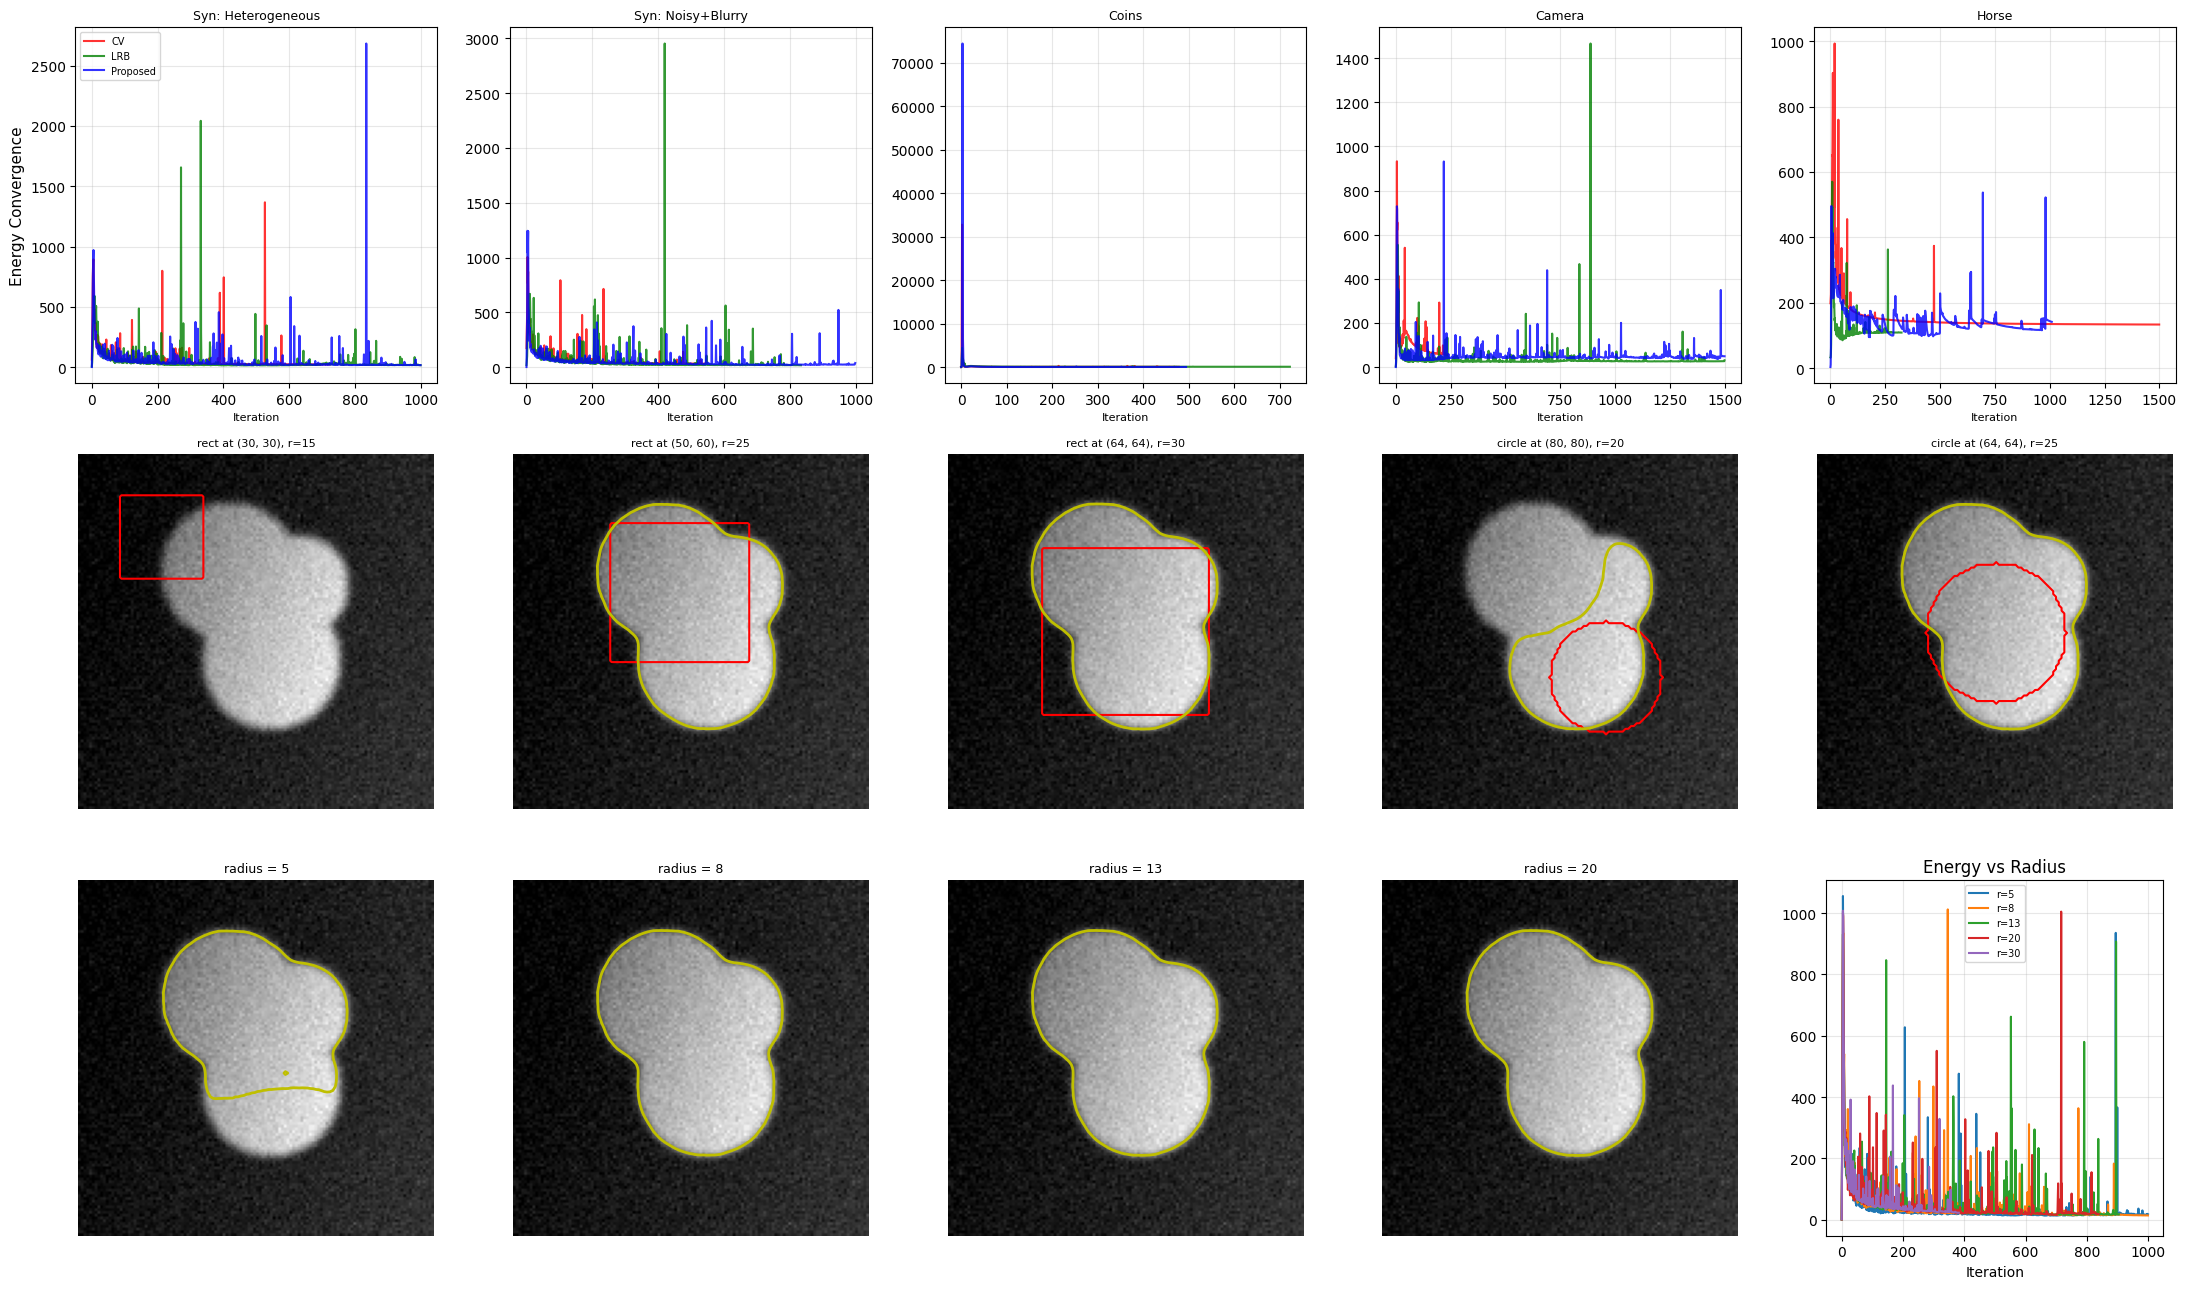

In [15]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))

# ── Row 0: Energy convergence for each image ──
for i, (name, (e_cv, e_lrb, e_hyb)) in enumerate(all_energies.items()):
    axes[0, i].plot(e_cv,  'r-', label='CV',  alpha=.8)
    axes[0, i].plot(e_lrb, 'g-', label='LRB', alpha=.8)
    axes[0, i].plot(e_hyb, 'b-', label='Proposed', alpha=.8)
    axes[0, i].set_title(name, fontsize=9); axes[0, i].grid(True, alpha=.3)
    axes[0, i].set_xlabel('Iteration', fontsize=8)
    if i == 0: axes[0, i].set_ylabel('Energy'); axes[0, i].legend(fontsize=7)
axes[0, 0].set_ylabel('Energy Convergence', fontsize=11)

# ── Row 1: Sensitivity to initialization (Fig. 6) ──
inits = [((30,30),15,'rect'), ((50,60),25,'rect'), ((64,64),30,'rect'),
         ((80,80),20,'circle'), ((64,64),25,'circle')]
for i, (c, r, m) in enumerate(inits):
    phi0 = init_phi(syn1.shape, c, r, m)
    phi_f, _ = run_hybrid(syn1, phi0.copy(), niters=1000)
    axes[1, i].imshow(syn1)
    axes[1, i].contour(phi0, [0], colors='r', linewidths=1.5)
    axes[1, i].contour(phi_f, [0], colors='y', linewidths=2)
    axes[1, i].set_title(f'{m} at {c}, r={r}', fontsize=8); axes[1, i].axis('off')
axes[1, 0].set_ylabel('Init Sensitivity\n(Fig. 6)', fontsize=11)

# ── Row 2: Effect of local radius (Fig. 5) ──
phi0 = init_phi(syn1.shape, (50, 60), 25, 'rect')
radii = [5, 8, 13, 20, 30]
radius_energies = {}
for i, r in enumerate(radii):
    phi_f, eng = run_hybrid(syn1, phi0.copy(), radius=r, niters=1000)
    radius_energies[r] = eng
    if i < 4:
        axes[2, i].imshow(syn1)
        axes[2, i].contour(phi_f, [0], colors='y', linewidths=2)
        axes[2, i].set_title(f'radius = {r}', fontsize=9); axes[2, i].axis('off')
    else:
        axes[2, i].imshow(syn1)
        axes[2, i].contour(phi_f, [0], colors='y', linewidths=2)
        axes[2, i].set_title(f'radius = {r}', fontsize=9); axes[2, i].axis('off')
# Overlay energy plot on last panel
ax_e = axes[2, 4].twinx() if False else axes[2, 4]
axes[2, 4].clear()
for r, eng in radius_energies.items():
    axes[2, 4].plot(eng, label=f'r={r}')
axes[2, 4].set_title('Energy vs Radius'); axes[2, 4].legend(fontsize=7)
axes[2, 4].grid(True, alpha=.3); axes[2, 4].set_xlabel('Iteration')
axes[2, 0].set_ylabel('Radius Effect\n(Fig. 5)', fontsize=11)

plt.tight_layout(); plt.show()

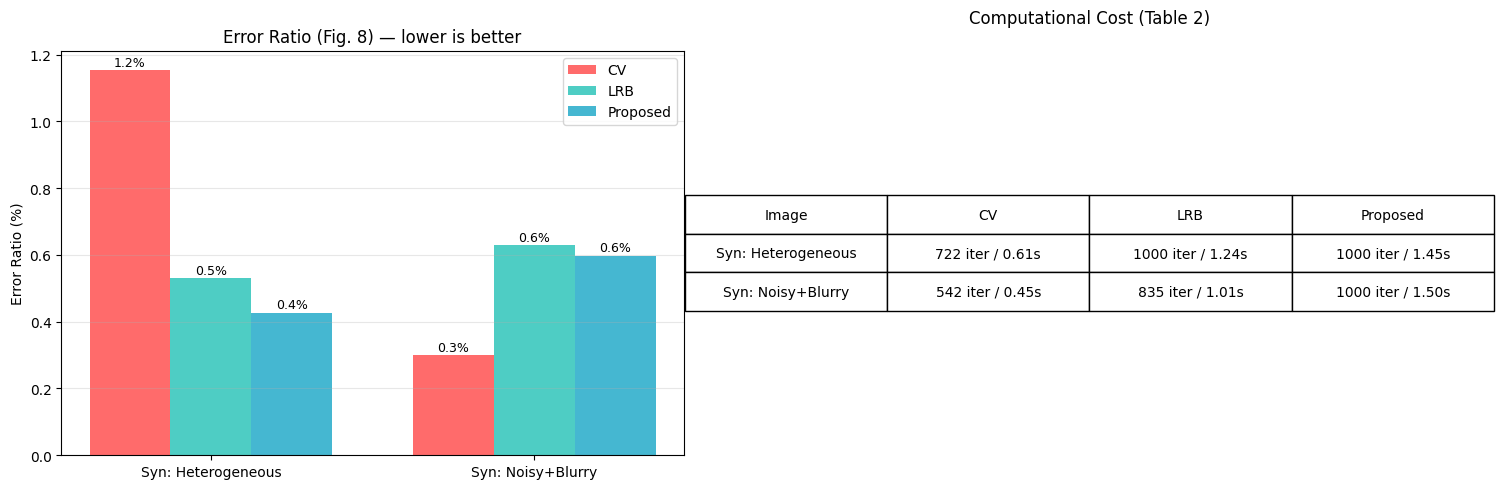


Error Ratio (%):
Image                           CV      LRB   Proposed
-------------------------------------------------------
Syn: Heterogeneous            1.2%     0.5%       0.4%
Syn: Noisy+Blurry             0.3%     0.6%       0.6%


In [16]:
def compute_er(phi, gt):
    """Error Ratio: ER = (FP + FN) / N × 100%"""
    seg = (phi >= 0)
    FP = np.sum(seg & ~gt); FN = np.sum(~seg & gt)
    return (FP + FN) / gt.size * 100

# ── Run all models on synthetic images with known ground truth ──
syn_cases = [
    ('Syn: Heterogeneous', syn1, gt1, (50,60), 25),
    ('Syn: Noisy+Blurry',  syn2, gt2, (64,64), 25),
]

er_results = {m: [] for m in ['CV', 'LRB', 'Proposed']}
timing     = {m: [] for m in ['CV', 'LRB', 'Proposed']}

for name, img, gt, center, rad in syn_cases:
    phi0 = init_phi(img.shape, center, rad, 'rect')
    r = max(img.shape) // 10
    for model_name, func, kw in [
        ('CV',       run_cv,     {}),
        ('LRB',      run_lrb,    {'radius': r}),
        ('Proposed', run_hybrid, {'radius': r}),
    ]:
        t0 = time.time()
        phi_f, eng = func(img, phi0.copy(), niters=1000, **kw)
        elapsed = time.time() - t0
        er_results[model_name].append(compute_er(phi_f, gt))
        timing[model_name].append((len(eng), elapsed))

# ── Plot: ER bar chart + timing table ──
names = [c[0] for c in syn_cases]
x = np.arange(len(names)); width = 0.25
colors = {'CV': '#ff6b6b', 'LRB': '#4ecdc4', 'Proposed': '#45b7d1'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, m in enumerate(['CV', 'LRB', 'Proposed']):
    bars = axes[0].bar(x + i*width, er_results[m], width, label=m, color=colors[m])
    for bar in bars:
        h = bar.get_height()
        axes[0].annotate(f'{h:.1f}%', xy=(bar.get_x()+bar.get_width()/2, h),
                         xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
axes[0].set_xticks(x + width); axes[0].set_xticklabels(names)
axes[0].set_ylabel('Error Ratio (%)'); axes[0].set_title('Error Ratio (Fig. 8) — lower is better')
axes[0].legend(); axes[0].grid(axis='y', alpha=.3)

axes[1].axis('off')
rows = []
for i, (name, *_) in enumerate(syn_cases):
    row = [name]
    for m in ['CV', 'LRB', 'Proposed']:
        it, t = timing[m][i]
        row.append(f'{it} iter / {t:.2f}s')
    rows.append(row)
table = axes[1].table(cellText=rows, colLabels=['Image', 'CV', 'LRB', 'Proposed'],
                       loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.3, 2.2)
axes[1].set_title('Computational Cost (Table 2)', fontsize=12, pad=20)

plt.tight_layout(); plt.show()

print("\nError Ratio (%):")
print(f"{'Image':<25} {'CV':>8} {'LRB':>8} {'Proposed':>10}")
print("-" * 55)
for i, (name, *_) in enumerate(syn_cases):
    print(f"{name:<25} {er_results['CV'][i]:>7.1f}% {er_results['LRB'][i]:>7.1f}% "
          f"{er_results['Proposed'][i]:>9.1f}%")

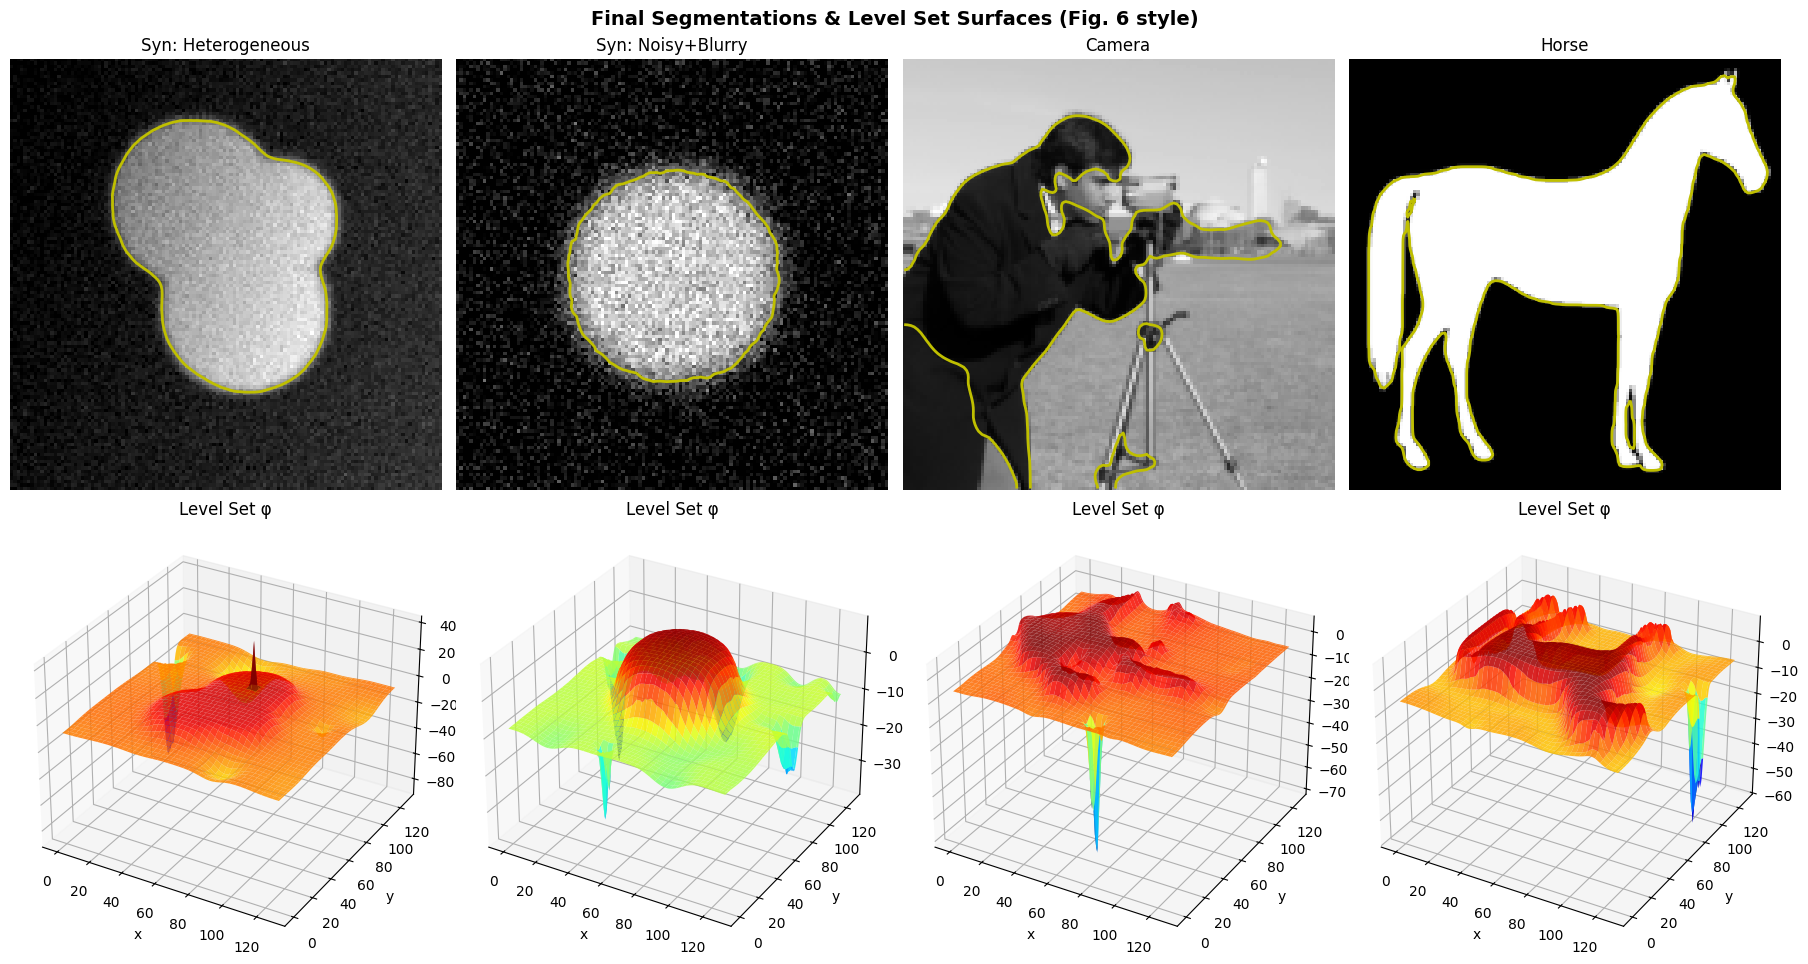

In [17]:
from mpl_toolkits.mplot3d import Axes3D

show = [
    ('Syn: Heterogeneous', syn1, (50,60), 25, 'rect',  0.1),
    ('Syn: Noisy+Blurry',  syn2, (64,64), 25, 'rect',  0.1),
    ('Camera',             cam,  (64,64), 30, 'rect',  0.05),
    ('Horse',              horse,(64,64), 25, 'rect',  0.05),
]

fig = plt.figure(figsize=(18, 10))
Yg, Xg = np.mgrid[:128, :128]

for i, (name, img, center, rad, method, mu) in enumerate(show):
    phi0 = init_phi(img.shape, center, rad, method)
    phi_f, _ = run_hybrid(img, phi0.copy(), niters=1500, mu=mu,
                           radius=max(img.shape) // 10)

    # Top row: segmentation overlay
    ax1 = fig.add_subplot(2, 4, i + 1)
    ax1.imshow(img)
    ax1.contour(phi_f, [0], colors='y', linewidths=2)
    ax1.set_title(name); ax1.axis('off')

    # Bottom row: 3D level set surface
    ax2 = fig.add_subplot(2, 4, i + 5, projection='3d')
    ax2.plot_surface(Xg, Yg, phi_f, cmap='jet', alpha=0.85, rstride=3, cstride=3)
    ax2.set_title('Level Set φ'); ax2.set_xlabel('x'); ax2.set_ylabel('y')

plt.suptitle('Final Segmentations & Level Set Surfaces (Fig. 6 style)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Successfully loaded 'mri.png' and resized to 128x128.
Evolving the hybrid contour for 1200 iterations...
Capturing at iterations: [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200]


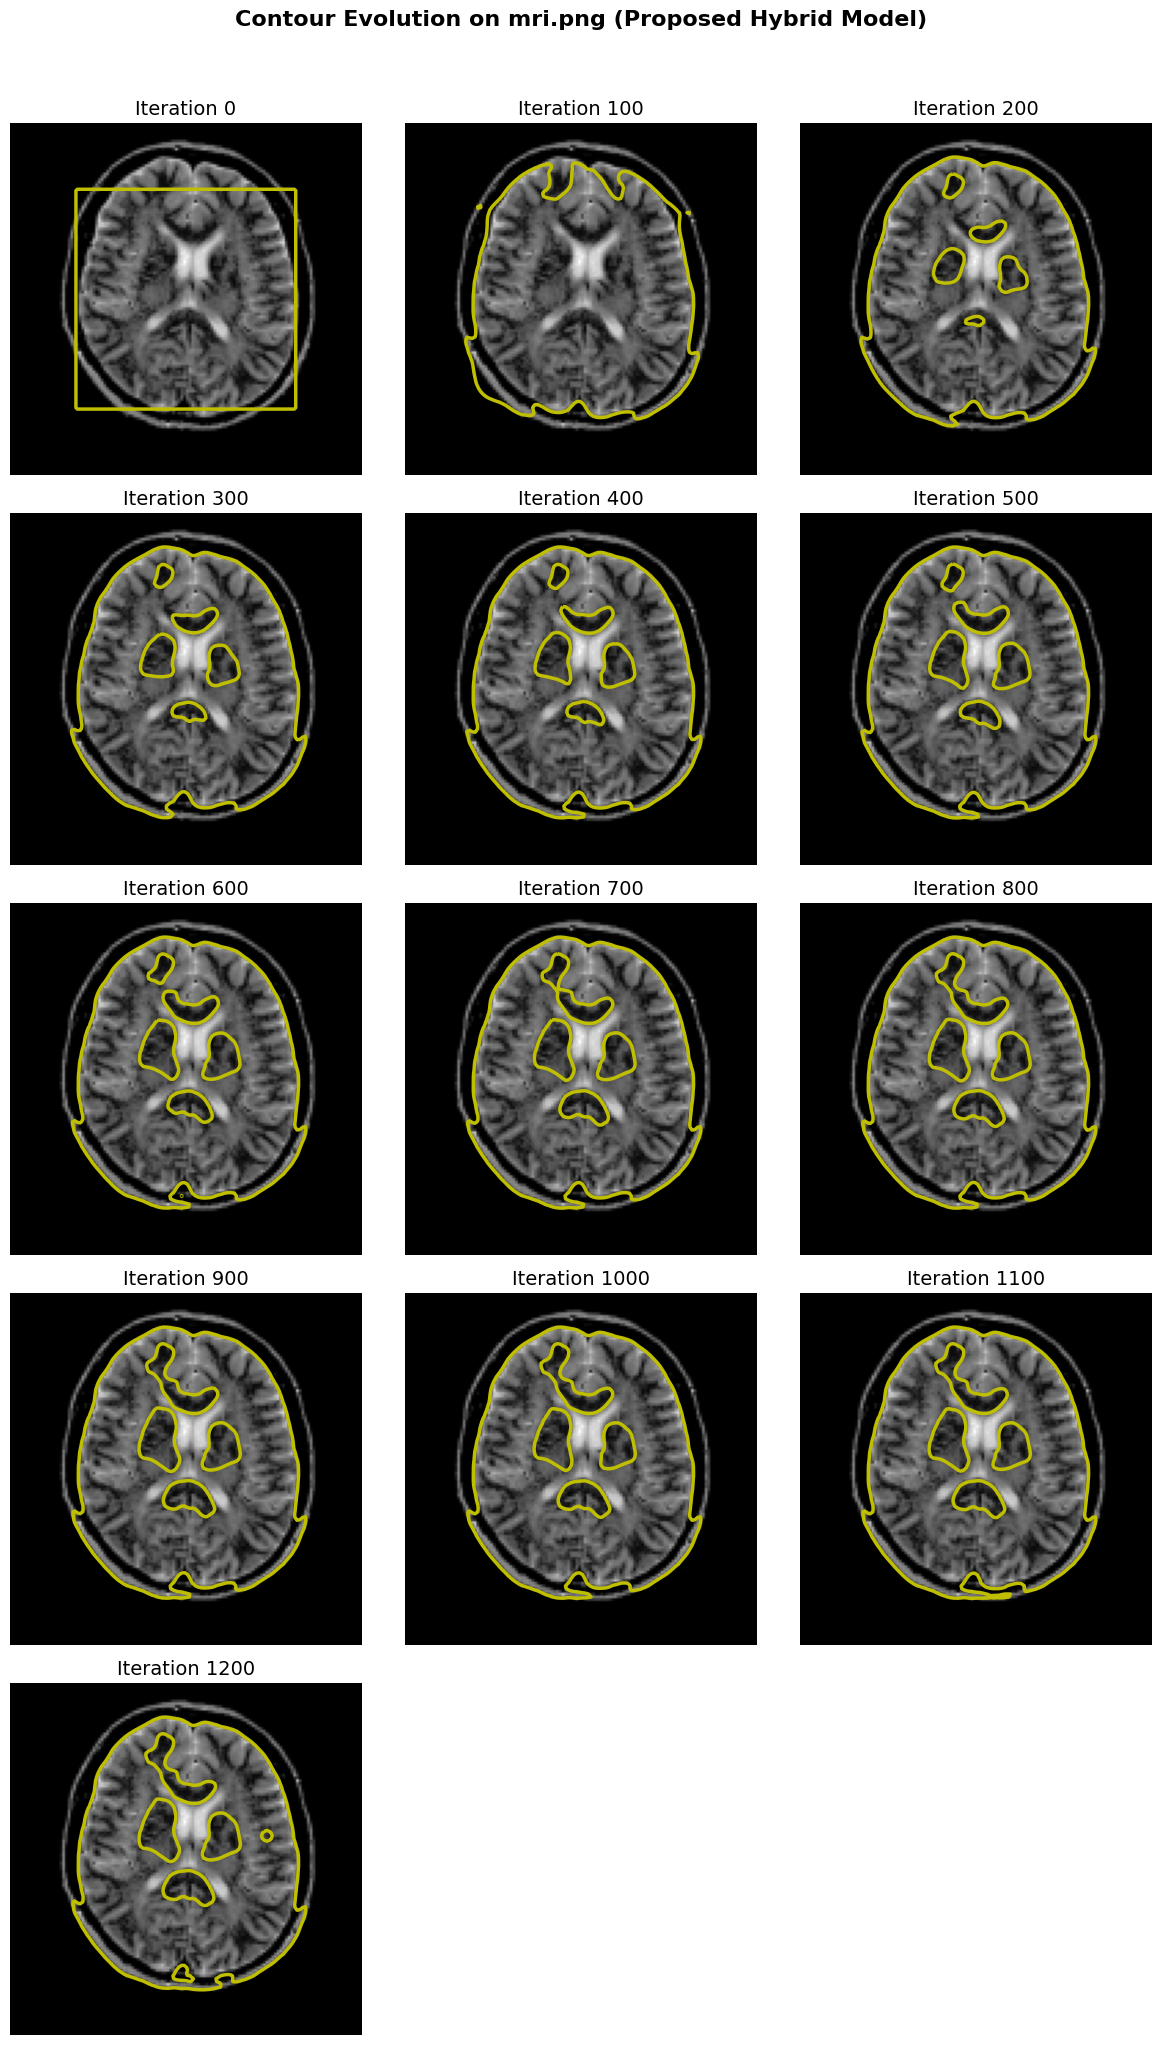

In [26]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, gaussian_filter
from skimage import io, color, img_as_float, transform

# ── 1. Load and preprocess the custom image ─────────────────────────────
image_path = 'mri.png'

if os.path.exists(image_path):
    # Load image, convert to grayscale if RGB, and scale to [0, 1]
    img = io.imread(image_path)
    if img.ndim == 3:
        img = color.rgb2gray(img)
    elif img.ndim == 4: # Handle RGBA
        img = color.rgb2gray(color.rgba2rgb(img))
    
    img = img_as_float(img)
    # Resize to 128x128 to match the performance of previous cells
    test_img = transform.resize(img, (128, 128), anti_aliasing=True)
    print(f"Successfully loaded '{image_path}' and resized to 128x128.")
else:
    print(f"Warning: '{image_path}' not found in the current directory.")
    print("Falling back to a library image to demonstrate the code execution.")
    from skimage import data
    test_img = transform.resize(img_as_float(data.astronaut()), (128, 128), anti_aliasing=True)
    if test_img.ndim == 3:
        test_img = color.rgb2gray(test_img)

# ── 2. Setup parameters and initialization ──────────────────────────────
niters = 1200             # Adjust this to your desired total iterations
capture_interval = 100    # Images will be captured at multiples of this number

dt = 5.0
mu = 0.05
eps = 1.0
sigma = 0.5
radius = max(test_img.shape) // 10

# Initialize a rectangular contour in the center
phi_current = init_phi(test_img.shape, center=(64, 64), radius=40, method='rect')

# Dynamically generate the capture list: [0, 250, 500, 750, ...]
capture_iters = list(range(0, niters + 1, capture_interval))
captured_phis = []

print(f"Evolving the hybrid contour for {niters} iterations...")
print(f"Capturing at iterations: {capture_iters}")

# ── 3. Evolve the contour and capture intermediate steps ────────────────
for i in range(niters + 1):
    # Save the current state if it matches a capture target
    if i in capture_iters:
        captured_phis.append((i, phi_current.copy()))
        
    if i == niters:
        break
        
    # Apply Proposed Hybrid Model (Eq. 12)
    neumann_bc(phi_current)
    c1, c2 = compute_c(test_img, phi_current, eps)
    m1, m2 = compute_m(test_img, phi_current, radius, eps)
    omega  = compute_omega(phi_current)
    
    E1 = omega * c1 - omega * c2
    E2 = test_img - (m1 + m2) / 2.0
    
    dphi = dirac(phi_current, eps) * (2.0 * E1 * E2 + mu * curvature_central(phi_current))
    phi_current = gaussian_filter(phi_current + dt * dphi, sigma=sigma)

# ── 4. Plot the evolution dynamically ───────────────────────────────────
num_plots = len(captured_phis)
cols = 3                                  # Fix to 3 columns for readability
rows = math.ceil(num_plots / cols)        # Calculate needed rows dynamically

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))

# Handle the case where axes might not be a 2D array if there's only 1 row
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

fig.suptitle(f'Contour Evolution on {image_path} (Proposed Hybrid Model)', 
             fontsize=16, fontweight='bold', y=1.02)

for i, ax in enumerate(axes):
    if i < num_plots:
        iter_num, phi_cap = captured_phis[i]
        ax.imshow(test_img)
        # Plot the zero-level set (the actual segmentation boundary)
        ax.contour(phi_cap, [0], colors='y', linewidths=2.5)
        ax.set_title(f'Iteration {iter_num}', fontsize=14)
        ax.axis('off')
    else:
        # Hide any unused subplots in the grid
        ax.axis('off')

plt.tight_layout()
plt.show()

Running all three models on the custom image to compute error ratios...

--- Error Ratios (vs. Otsu Pseudo-GT) ---
Model           Error Ratio     Time
---------------------------------------------
CV                10.58%       0.22s
LRB               10.80%       1.16s
Proposed          10.25%       1.47s


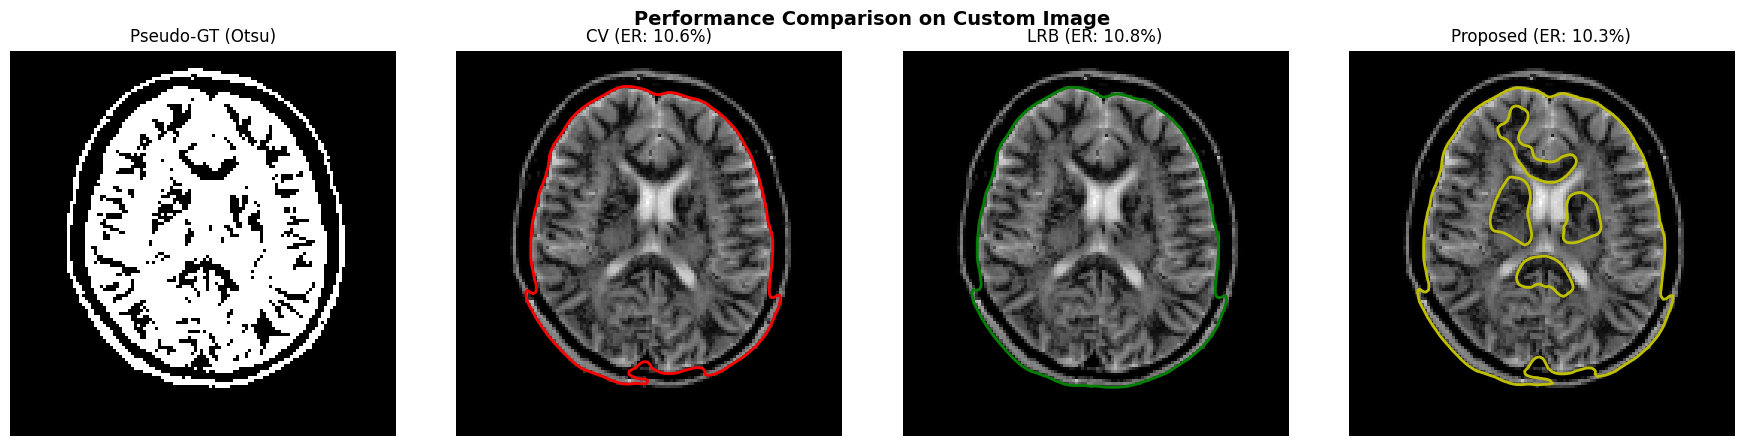

In [27]:
from skimage.filters import threshold_otsu
import time

# ── 1. Create a Pseudo-Ground Truth ─────────────────────────────────────
# Since we don't have a manual ground truth for the custom image, 
# we use Otsu's thresholding to create a baseline binary mask.
thresh = threshold_otsu(test_img)
gt_custom = test_img > thresh

# ── 2. Initialize Parameters for the Custom Image ───────────────────────
phi0_custom = init_phi(test_img.shape, center=(64, 64), radius=40, method='rect')
r_custom = max(test_img.shape) // 10
params_custom = dict(dt=5.0, mu=0.05, eps=1.0, sigma=0.5, niters=1000)

print("Running all three models on the custom image to compute error ratios...")

# ── 3. Run Models ───────────────────────────────────────────────────────
# CV Model
t0 = time.time()
phi_cv_custom, _ = run_cv(test_img, phi0_custom.copy(), **params_custom)
time_cv = time.time() - t0

# LRB Model
t0 = time.time()
phi_lrb_custom, _ = run_lrb(test_img, phi0_custom.copy(), radius=r_custom, **params_custom)
time_lrb = time.time() - t0

# Proposed Hybrid Model
t0 = time.time()
phi_hyb_custom, _ = run_hybrid(test_img, phi0_custom.copy(), radius=r_custom, **params_custom)
time_hyb = time.time() - t0

# ── 4. Compute Error Ratios ─────────────────────────────────────────────
er_cv = compute_er(phi_cv_custom, gt_custom)
er_lrb = compute_er(phi_lrb_custom, gt_custom)
er_hyb = compute_er(phi_hyb_custom, gt_custom)

# ── 5. Print Results & Plot ─────────────────────────────────────────────
print("\n--- Error Ratios (vs. Otsu Pseudo-GT) ---")
print(f"{'Model':<15} {'Error Ratio':<15} {'Time'}")
print("-" * 45)
print(f"{'CV':<15} {er_cv:>7.2f}% {time_cv:>10.2f}s")
print(f"{'LRB':<15} {er_lrb:>7.2f}% {time_lrb:>10.2f}s")
print(f"{'Proposed':<15} {er_hyb:>7.2f}% {time_hyb:>10.2f}s")

# Plot the comparisons
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle('Performance Comparison on Custom Image', fontsize=14, fontweight='bold')

axes[0].imshow(gt_custom, cmap='gray')
axes[0].set_title('Pseudo-GT (Otsu)')
axes[0].axis('off')

axes[1].imshow(test_img)
axes[1].contour(phi_cv_custom, [0], colors='r', linewidths=2)
axes[1].set_title(f'CV (ER: {er_cv:.1f}%)')
axes[1].axis('off')

axes[2].imshow(test_img)
axes[2].contour(phi_lrb_custom, [0], colors='g', linewidths=2)
axes[2].set_title(f'LRB (ER: {er_lrb:.1f}%)')
axes[2].axis('off')

axes[3].imshow(test_img)
axes[3].contour(phi_hyb_custom, [0], colors='y', linewidths=2)
axes[3].set_title(f'Proposed (ER: {er_hyb:.1f}%)')
axes[3].axis('off')

plt.tight_layout()
plt.show()